# Convolucion y kernel. INTRODUCCION

---

In [18]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2

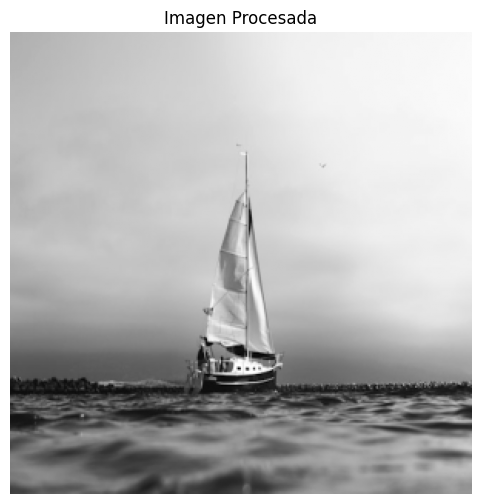

In [19]:
# Configuración de ruta
path = '../img/barco.jpg'

# Verificación de existencia del archivo
if not os.path.exists(path):
    raise FileNotFoundError(f"No se encontró el archivo en la ruta: {path}")

# Carga de la imagen
img = cv2.imread(path, cv2.IMREAD_COLOR)
# Cambio a gris
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Redimensionamiento optimizado a un mejor tamaño
img_resized = cv2.resize(img_gray, (300, 300), interpolation=cv2.INTER_AREA)

plt.figure(figsize=(6, 6))
plt.imshow(img_resized, cmap='gray')
plt.title('Imagen Procesada')
plt.axis('off')
plt.show()

In [20]:
f_list=[3,3,2,1,0,0,0,1,3,1,3,1,2,2,3,2,0,0,2,2,2,0,0,0,1]
f=np.array(f_list).reshape(5,5)
f

array([[3, 3, 2, 1, 0],
       [0, 0, 1, 3, 1],
       [3, 1, 2, 2, 3],
       [2, 0, 0, 2, 2],
       [2, 0, 0, 0, 1]])

In [21]:
w_list=[0,1,2,2,2,0,0,1,2]
w=np.array(w_list).reshape(3,3)
w

array([[0, 1, 2],
       [2, 2, 0],
       [0, 1, 2]])

In [22]:
# f: Imagen de entrada y w: Kernel
def convolucion_2d(f,w):
  #Dimensiones de la imagen y el kernel
  f_h,f_w=f.shape
  w_h,w_w=w.shape

  #Tamaño de la imagen de salida sin padding y stride 1
  out_h=f_h-w_h+1
  out_w=f_w-w_w+1
  img_out=np.zeros((out_h,out_w))

  for i in range(out_h):
    for j in range(out_w):
      roi=f[i:i+w_h,j:j+w_w]
      img_out[i,j]=np.sum(roi*w)

  img_out=np.clip(img_out,0,255)
  return img_out

In [23]:
convolucion_2d(f,w)

array([[12., 12., 17.],
       [10., 17., 19.],
       [ 9.,  6., 14.]])

In [24]:
# Filtro de Enfoque (Sharpen)
kernel_sharpen = np.array([[ 0, -1,  0],
                           [-1,  5, -1],
                           [ 0, -1,  0]])

# Filtro de Desenfoque (Blur / Caja)
kernel_blur = np.array([[1, 1, 1],
                        [1, 1, 1],
                        [1, 1, 1]]) / 9.0

# Filtro Sobel Vertical (Detector de bordes verticales)
kernel_sobel_v = np.array([[-1, 0, 1],
                           [-2, 0, 2],
                           [-1, 0, 1]])

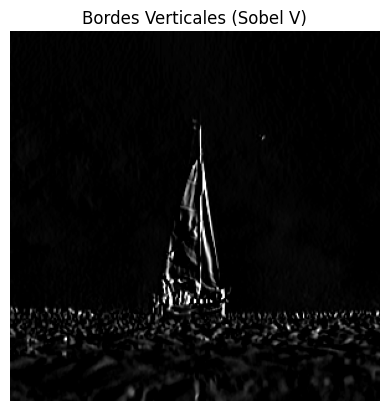

In [25]:
img_edge=convolucion_2d(img_resized,kernel_sobel_v)
plt.imshow(img_edge, cmap='gray'); plt.title('Bordes Verticales (Sobel V)')
plt.axis('off')
plt.show()

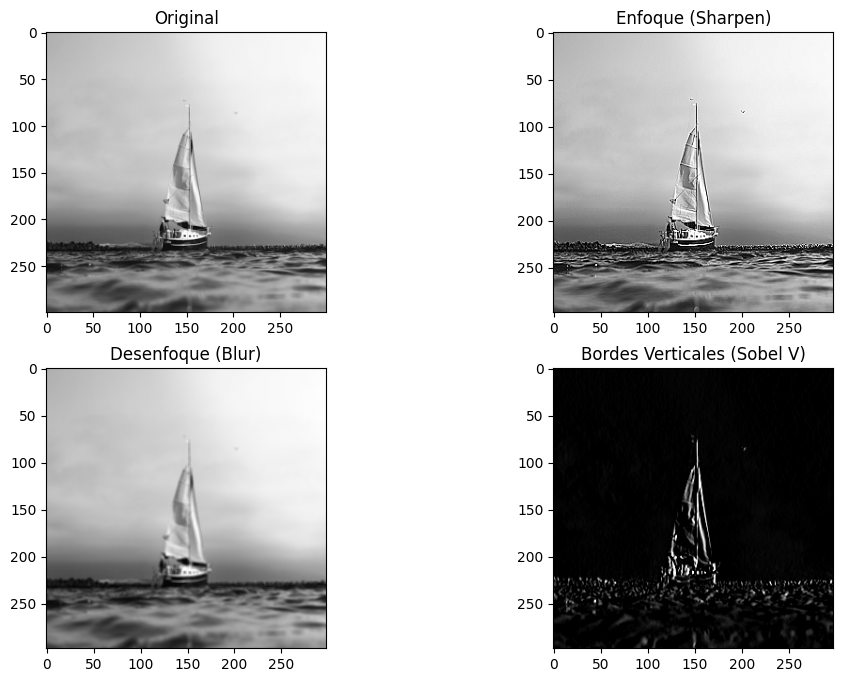

In [26]:
res_sharpen = convolucion_2d(img_resized, kernel_sharpen)
res_blur = convolucion_2d(img_resized, kernel_blur)
res_sobel = convolucion_2d(img_resized, kernel_sobel_v)

plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1); plt.imshow(img_resized, cmap='gray'); plt.title('Original')
plt.subplot(2, 2, 2); plt.imshow(res_sharpen, cmap='gray'); plt.title('Enfoque (Sharpen)')
plt.subplot(2, 2, 3); plt.imshow(res_blur, cmap='gray'); plt.title('Desenfoque (Blur)')
plt.subplot(2, 2, 4); plt.imshow(res_sobel, cmap='gray'); plt.title('Bordes Verticales (Sobel V)')
plt.show()

# Práctica de Laboratorio: Redes Neuronales Convolucionales Avanzadas

---

### Objetivos de la Sesión:
1. **Dominar Keras Profesional:** Comprender la diferencia práctica entre la API Secuencial y la API Funcional, así como el uso estratégico de Callbacks en entornos de producción.
2. **Evolución contra el Overfitting:** Construir una CNN manual y analizar cómo mitigar el sobreajuste mediante técnicas avanzadas (Aumento de Datos).
3. **Ingeniería Colaborativa (Transfer Learning):** Dividir el grupo en equipos para evaluar, comparar y defender técnicamente diferentes arquitecturas globales preentrenadas (*ResNet, VGG, Xception, MobileNet, DenseNet*).

---

## Bloque de Auditoría: Verificación de Aceleración por Hardware (GPU)

El entrenamiento de redes neuronales profundas requiere billones de operaciones de multiplicación de matrices. Ejecutar esto en un procesador genérico (CPU) puede tomar horas. Las Unidades de Procesamiento Gráfico (**GPU**) permiten paralelizar estas operaciones, reduciendo el tiempo de minutos a segundos.

### ¿Cómo activar la GPU en Google Colab?
1. Ve al menú superior: **Entorno de ejecución** $\rightarrow$ **Cambiar tipo de entorno de ejecución**.
2. En la opción *Acelerador por hardware*, selecciona **T4 GPU**.
3. Da clic en **Guardar** *(Nota: Esto reiniciará el entorno, recuerda volver a correr la celda de carga de datos).*

### ¿Cómo verificarlo en un Jupyter Notebook Local?
Si corres este código en tu computadora, TensorFlow buscará tarjetas gráficas NVIDIA compatibles con los controladores CUDA instalados en tu sistema operativo.
*(Nota de ingeniería: Recuerda que las versiones modernas de TensorFlow en Windows nativo requieren el uso de WSL2 para poder detectar la GPU).*

In [27]:
import tensorflow as tf
import os

print("--- DIAGNÓSTICO DE HARDWARE TENSORFLOW ---")

# 1. Comprobar si TensorFlow tiene acceso a alguna GPU
dispositivos_gpu = tf.config.list_physical_devices('GPU')

if len(dispositivos_gpu) > 0:
    print(f"\n¡ÉXITO! Se detectaron {len(dispositivos_gpu)} GPU(s) disponibles.")
    for i, gpu in enumerate(dispositivos_gpu):
        print(f"  - GPU {i}: {gpu}")

    # Obtener el nombre comercial del dispositivo asignado por Keras
    nombre_gpu = tf.test.gpu_device_name()
    print(f"\nDispositivo activo para Keras: {nombre_gpu}")
else:
    print("\n ADVERTENCIA: No se detectó ninguna GPU. TensorFlow está corriendo en CPU.")
    print("Si estás en Colab, ve a Entorno de ejecución -> Cambiar tipo de entorno -> T4 GPU.")

print("\n-----------------------------------------")

# 2. Comando de bajo nivel de NVIDIA (Solo funciona en Linux/Colab o entornos locales con drivers instalados)
# El comando de consola '!nvidia-smi' nos da el reporte de consumo de memoria y el modelo exacto en tiempo real.
try:
    print("Reporte oficial de la tarjeta de video (nvidia-smi):")
    print("====================================================")
    os.system('nvidia-smi --query-gpu=name,memory.total,memory.free --format=csv')
except:
    print("Comando nvidia-smi no disponible en este sistema operativo (común en Windows nativo sin WSL2 o macOS).")

--- DIAGNÓSTICO DE HARDWARE TENSORFLOW ---

 ADVERTENCIA: No se detectó ninguna GPU. TensorFlow está corriendo en CPU.
Si estás en Colab, ve a Entorno de ejecución -> Cambiar tipo de entorno -> T4 GPU.

-----------------------------------------
Reporte oficial de la tarjeta de video (nvidia-smi):


## Bloque 1: Repaso Arquitectónico (Capítulo 7 de Keras)

Antes de entrenar, un ingeniero en IA debe elegir el paradigma de programación adecuado. Keras nos ofrece dos caminos principales:

### 1. API Secuencial (`tf.keras.Sequential`)
* **Qué es:** Una pila lineal de capas donde cada capa tiene exactamente un tensor de entrada y un tensor de salida.
* **Limitación:** Es incapaz de procesar modelos con conexiones no lineales, múltiples entradas, múltiples salidas o **conexiones de salto (Skip Connections)** como las que requiere *ResNet*.

### 2. API Funcional (`tf.keras.Model`)
* **Qué es:** Trata a las capas como funciones matemáticas explícitas. Permite crear grafos acíclicos dirigidos de capas.
* **Por qué la usamos hoy:** Es el estándar de la industria para diseñar arquitecturas complejas y personalizadas.

In [28]:
import tensorflow as tf
import keras
from keras import layers

print("Versión de TensorFlow:", tf.__version__)

Versión de TensorFlow: 2.21.0


In [29]:
# DEMOSTRACIÓN EN VIVO: APIS DE KERAS
# 1. Enfoque Secuencial (Limitado)
modelo_secuencial = keras.Sequential([
    layers.Input(shape=(180, 180, 3)),
    layers.Conv2D(32, 3, activation="relu"),
    layers.Flatten(),
    layers.Dense(1, activation="sigmoid")
], name="Modelo_Secuencial")
modelo_secuencial.summary()

Model: "Modelo_Secuencial"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1013888)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │     1,013,889 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,014,785 (3.87 MB)

 Trainable params: 1,014,785 (3.87 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
# 2. Enfoque Funcional (Flexible - Estándar de la Industria)
inputs = keras.Input(shape=(180, 180, 3), name="Input_Tensor")
x = layers.Conv2D(32, 3, activation="relu", name="Capa_Conv_1")(inputs)
x = layers.Flatten(name="Aplanado")(x)
outputs = layers.Dense(1, activation="sigmoid", name="Output_Clasificador")(x)

modelo_funcional = keras.Model(inputs=inputs, outputs=outputs, name="Modelo_Funcional")

# Mostramos un resumen rápido en consola
modelo_funcional.summary()

Model: "Modelo_Funcional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input_Tensor (InputLayer)       │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Capa_Conv_1 (Conv2D)            │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Aplanado (Flatten)              │ (None, 1013888)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Clasificador (Dense)     │ (None, 1)              │     1,013,889 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,014,785 (3.87 MB)

 Trainable params: 1,014,785 (3.87 MB)

 Non-trainable params: 0 (0.00 B)

#### NOTAS SOBRE API FUNCIONAL


##### Profundización Técnica: API Secuencial vs. API Funcional (Keras Avanzado)

Para construir la arquitectura de nuestra CNN el día de hoy, dejaremos atrás el enfoque básico (`Sequential`) y utilizaremos el estándar profesional de la industria: la **API Funcional** (`tf.keras.Model`).

---

###### Comparativa Rápida de Paradigmas

| Característica | API Secuencial (`Sequential`) | API Funcional (`Model`) |
| :--- | :--- | :--- |
| **Estructura Visual** | Pila lineal y rígida de capas (línea recta). | Grafo Acíclico Dirigido (DAG) flexible (red/malla). |
| **Flujo de Datos** | Entrada única $\rightarrow$ Salida única. Sin desviaciones. | Múltiples entradas, múltiples salidas o bifurcaciones intermedias. |
| **Capacidad ResNet** | **Imposible** de programar. | **Nativa y natural** mediante operaciones de suma de tensores. |
| **Casos de Uso** | Modelos educativos básicos o prototipos rápidos. | Modelos de producción reales (*Inception, ResNet, Transformers*). |

---

#### El Vínculo Matemático: ¿Por qué migramos hoy a la API Funcional?

Recordemos la teoría fundamental de las **Redes Residuales (ResNet)**. Para combatir el desvanecimiento del gradiente (*vanishing gradient*) en redes profundas, ResNet introduce una **Conexión de Salto (Skip Connection)**, expresada matemáticamente como:

$$H(x) = F(x) + x$$

Donde $x$ es la identidad original y $F(x)$ es el procesamiento de las capas convolucionales intermedias.
* En un bloque `Sequential` no existe manera de guardar la identidad $x$ y saltarse capas para sumarla más adelante.
* En la **API Funcional**, al tratar a las capas como funciones explícitas, podemos guardar un tensor en una variable intermedia (ej. `shortcut = x`), dejar que el flujo principal continúe, y sumarlos al final con una capa matemática: `outputs = layers.add([x, shortcut])`.

---

###### Anatomía del Código Funcional (En qué debemos fijarnos)

1. **Capas como Funciones OOO (Doble Paréntesis):** En lugar de "añadir" capas a una lista inerte, cada capa se comporta como una función matemática pura:
   ```python
   x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(inputs)

* Primer bloque de paréntesis: Configura la capa (los hiperparámetros del operador).

* Segundo bloque de paréntesis: Recibe el tensor de entrada sobre el cual operará.

2. **La Variable Mutante x:** Notarán que en la programación funcional reescribimos constantemente la variable x = Capa(...)(x). Esto representa el viaje y transformación continua del flujo de datos (tensores) a través de las aristas del grafo.

3. **El Amarre Final del Grafo:** A diferencia del modelo secuencial, la red funcional no sabe que es un modelo unido sino hasta la última línea de código. Ahí le indicamos explícitamente a Keras los puntos extremos de nuestro mapa de datos:
   ```python
   mi_modelo = keras.Model(inputs=inputs, outputs=outputs)

Keras automáticamente viaja en reversa desde el output final hasta el input inicial para trazar el grafo y compilarlo en memoria.

### El Control del Tiempo y Recursos: Callbacks de Keras

Entrenar modelos a "ciegas" durante decenas de épocas es ineficiente en costos de cómputo y tiempo de aula. Utilizaremos dos herramientas cruciales del Capítulo 7:

1. **`EarlyStopping`:** Monitorea la pérdida de validación (`val_loss`). Si el modelo deja de mejorar durante un número determinado de épocas (`patience`), detiene el entrenamiento de inmediato.
2. **`ModelCheckpoint`:** Guarda automáticamente en el disco de Colab la mejor versión del modelo encontrada hasta el momento, protegiendo nuestro progreso ante caídas de entorno o sobreajuste posterior.

In [ ]:
# Definición de Callbacks 
mis_callbacks = [
    # Si la pérdida de validación no mejora en 3 épocas, detenemos el entrenamiento
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True # Regresa automáticamente a los pesos de la mejor época
    ),
    # Guardamos en la raíz de Colab únicamente el mejor modelo basado en val_loss
    keras.callbacks.ModelCheckpoint(
        filepath="mejor_modelo_clase.keras",
        save_best_only=True,
        monitor="val_loss"
    )
]

print("Callbacks configurados correctamente y listos para producción.")

Callbacks configurados correctamente y listos para producción.


---
## Bloque 2: Preparación del Dataset (Cats vs Dogs Filtered)

Para optimizar el ancho de banda de la universidad y asegurar que las épocas corran en segundos, utilizaremos el dataset oficial filtrado de Google de **3,000 imágenes** (en lugar de las 25,000 originales de Kaggle).

* **Entrenamiento:** 2,000 imágenes (1,000 gatos, 1,000 perros).
* **Validación:** 1,000 imágenes (500 gatos, 500 perros).

**Profecía de Cátedra:** Al tener un conjunto de datos tan pequeño, nuestra primera red convolucional manual sufrirá un **sobreajuste (overfitting) masivo**. Esto nos servirá para justificar la necesidad del Data Augmentation y el Transfer Learning.

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("birajsth/cats-and-dogs-filtered")

print("Path to dataset files:", path)

ModuleNotFoundError: No module named 'google.colab'

In [ ]:
# 3. Mapeo inteligente de rutas (Verificamos si viene anidado)
if 'cats_and_dogs_filtered' in os.listdir(path_dataset):
    PATH = os.path.join(path_dataset, 'cats_and_dogs_filtered')
else:
    PATH = path_dataset

train_dir = os.path.join(PATH, 'train')
validation_dir = os.path.join(PATH, 'validation')

In [ ]:
# 4. Pipeline de datos optimizado usando tf.keras.utils
BATCH_SIZE = 32
IMG_SIZE = (180, 180)

In [ ]:
print("\n--- Cargando Set de Entrenamiento ---")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

print("\n--- Cargando Set de Validación ---")
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    validation_dir,
    shuffle=False,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)


--- Cargando Set de Entrenamiento ---
Found 2000 files belonging to 2 classes.

--- Cargando Set de Validación ---
Found 1000 files belonging to 2 classes.


In [ ]:
# =====================================================================
# PARTICIONAMIENTO DEL SET DE VALIDACIÓN EN VALIDACIÓN Y TEST (50/50)
# =====================================================================

# Almacenamos cuántos lotes (batches) totales tiene el set de validación original
# 1,000 imágenes / 32 BATCH_SIZE = ~32 lotes
lotes_totales = validation_dataset.cardinality().numpy()
lotes_val = lotes_totales // 2

# Creamos el set de validación real (toma la primera mitad de los lotes)
val_dataset_puro = validation_dataset.take(lotes_val)

# Creamos el set de prueba final (se salta la primera mitad y toma el resto)
test_dataset = validation_dataset.skip(lotes_val)

print(f"Estructura final de datos optimizada:")
print(f"  - Lotes de Entrenamiento: {train_dataset.cardinality().numpy()} (~2000 imágenes)")
print(f"  - Lotes de Validación Pura: {val_dataset_puro.cardinality().numpy()} (~500 imágenes)")
print(f"  - Lotes de Test Definitivo: {test_dataset.cardinality().numpy()} (~500 imágenes)")

Estructura final de datos optimizada:
  - Lotes de Entrenamiento: 63 (~2000 imágenes)
  - Lotes de Validación Pura: 16 (~500 imágenes)
  - Lotes de Test Definitivo: 16 (~500 imágenes)


Organizacion del dataset:



```
cats_and_dogs_filtered/
├── train/                  <-- Carpeta de entrenamiento
│   ├── cats/               <-- 1,000 imágenes de gatos (ej. cat.1.jpg, cat.2.jpg...)
│   └── dogs/               <-- 1,000 imágenes de perros (ej. dog.1.jpg, dog.2.jpg...)
└── validation/             <-- Carpeta de validación
    ├── cats/               <-- 500 imágenes de gatos
    └── dogs/               <-- 500 imágenes de perros
```



¿Qué hace internamente image_dataset_from_directory?


Esta función no carga las 3,000 imágenes a la memoria RAM de golpe (eso saturaría las computadoras locales). En su lugar, crea un Generador de datos (tf.data.Dataset).

Internamente, hace cuatro tareas de ingeniería sobre la marcha (on-the-fly):

* Decodificación: Convierte los archivos .jpg pesados en matrices numéricas (Tensores).

* Redimensionamiento (Resize): Modifica el tamaño original de la foto (venga en la resolución que venga) a exactamente (180, 180) píxeles, porque las CNNs exigen que todas las entradas tengan el mismo tamaño dimensional.

* Loteado (Batching): Agrupa las imágenes en paquetes de 32 (BATCH_SIZE = 32). Cada que el modelo pida datos, este generador le entregará un bloque de 32 fotos con sus 32 etiquetas.

* Barajado (Shuffle): Mezcla las imágenes para que en un solo lote vayan perros y gatos revueltos, evitando que la red memorice secuencias.

### Bloque 2B: Análisis Exploratorio de Datos (EDA)

Antes de construir código matemático, un ingeniero en Inteligencia Artificial debe responder tres preguntas fundamentales:
1. ¿Cómo están estructuradas las carpetas en el disco?
2. ¿Qué nombres de clases detectó automáticamente TensorFlow?
3. ¿Cuál es la forma (*shape*) de los tensores que entrarán a nuestra red?

In [ ]:
# 1. Verificar las clases detectadas automáticamente por la función
nombres_clases = train_dataset.class_names
print("Las clases detectadas y su orden alfabético son:", nombres_clases)
print(f"Por lo tanto: {nombres_clases[0]} = 0, y {nombres_clases[1]} = 1\n")

# 2. Extraer UN SOLO LOTE (Batch) para inspeccionar la anatomía de los tensores
# .take(1) le pide al generador que nos entregue únicamente el primer paquete de 32 imágenes
for lote_imagenes, lote_etiquetas in train_dataset.take(1):
    print("ANATOMÍA DEL LOTE RECIBIDO POR TENSORFLOW:")
    print("------------------------------------------")
    print("Forma del tensor de imágenes (Batch, Alto, Ancho, Canales Color):", lote_imagenes.shape)
    print("Forma del tensor de etiquetas:", lote_etiquetas.shape)
    print("\nPrimeras 10 etiquetas numéricas de este lote (mezcladas):", lote_etiquetas.numpy()[:10])

Las clases detectadas y su orden alfabético son: ['cats', 'dogs']
Por lo tanto: cats = 0, y dogs = 1

ANATOMÍA DEL LOTE RECIBIDO POR TENSORFLOW:
------------------------------------------
Forma del tensor de imágenes (Batch, Alto, Ancho, Canales Color): (32, 180, 180, 3)
Forma del tensor de etiquetas: (32,)

Primeras 10 etiquetas numéricas de este lote (mezcladas): [1 1 0 1 1 0 0 0 0 0]


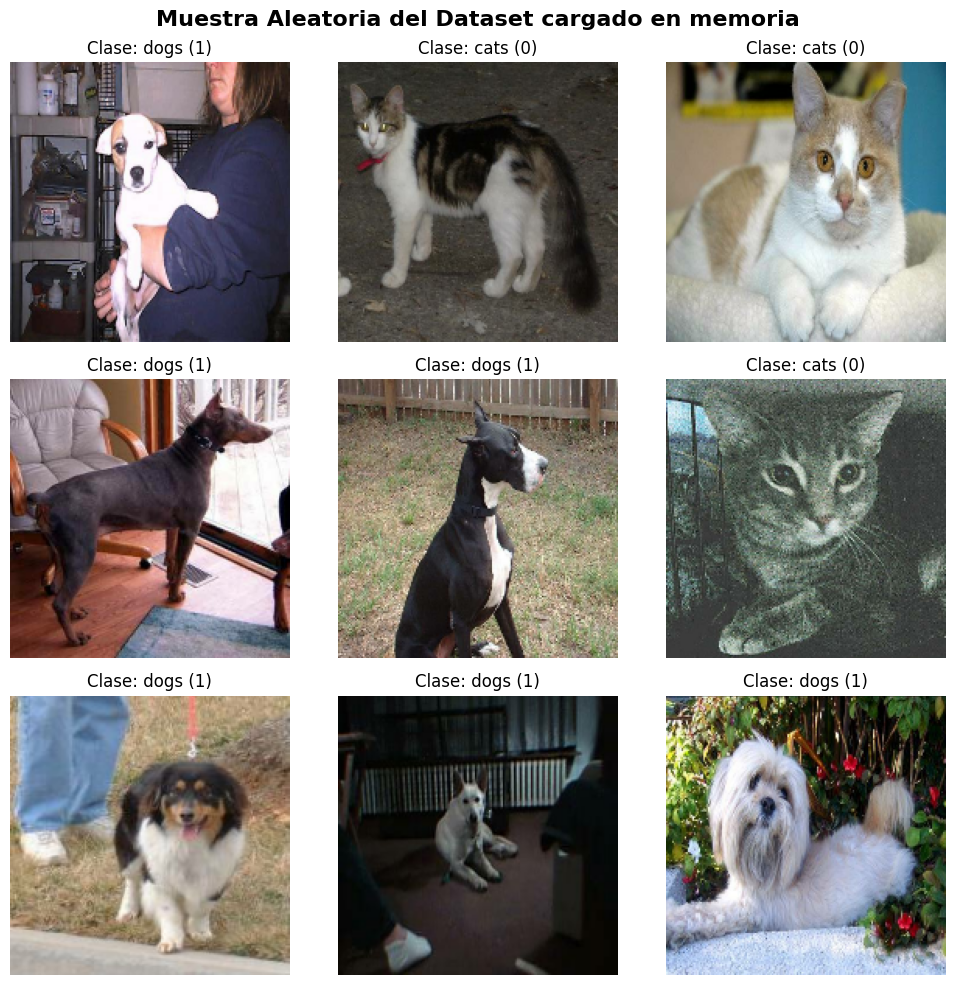

In [ ]:
import matplotlib.pyplot as plt

# Graficamos una muestra visual de nuestro dataset
plt.figure(figsize=(10, 10))

# Tomamos 1 lote del set de entrenamiento
for imagenes, etiquetas in train_dataset.take(1):
    for i in range(9): # Mostramos las primeras 9 imágenes del lote
        ax = plt.subplot(3, 3, i + 1)
        # Keras carga las imágenes como flotantes, las casteamos a enteros para Matplotlib
        plt.imshow(imagenes[i].numpy().astype("uint8"))

        # Obtenemos el nombre de la clase usando el índice de la etiqueta
        clase_actual = nombres_clases[etiquetas[i]]

        plt.title(f"Clase: {clase_actual} ({etiquetas[i].numpy()})")
        plt.axis("off")

plt.suptitle("Muestra Aleatoria del Dataset cargado en memoria", fontsize=16, weight='bold')
plt.tight_layout()
plt.show()

## Bloque 3: Diseño de una CNN Manual Base (Sin Regularización)

Vamos a construir nuestra primera Red Neuronal Convolucional clásica desde cero, siguiendo el patrón jerárquico del **Capítulo 8**: una serie de bloques alternados de Convolución y Max Pooling, terminando en un clasificador denso (MLP).

### Puntos clave del diseño en los que deben fijarse:
1. **Capa de Normalización (`Rescaling`):** Los valores de los píxeles en las imágenes van de `0` a `255`. Las redes neuronales calculan gradientes de forma mucho más estable si los datos de entrada están normalizados en un rango de `[0, 1]`. Escalamos multiplicando por `1./255`.
2. **Crecimiento de Filtros:** Noten cómo duplicamos el número de filtros en cada bloque (`32 -> 64 -> 128`). Las primeras capas extraen rasgos geométricos simples (bordes, líneas); las capas más profundas necesitan más filtros para combinar esos bordes y memorizar texturas complejas.
3. **Reducción Espacial:** Cada capa de `MaxPooling2D` reduce las dimensiones de alto y ancho a la mitad, forzando a la red a ser invariante a la traslación y reduciendo la carga computacional.

In [ ]:
# =====================================================================
# CONSTRUCCIÓN DE LA CNN MANUAL (API FUNCIONAL)
# =====================================================================

# 1. Definición de la Entrada (Mismo tamaño que configuramos en el dataset)
inputs = keras.Input(shape=(180, 180, 3), name="Input_Visual")

# 2. Preprocesamiento: Escalar píxeles de [0, 255] a [0, 1]
x = layers.Rescaling(1./255, name="Normalizacion_Pixeles")(inputs)

# Bloque Convolucional 1: Extrae características de bajo nivel
x = layers.Conv2D(filters=32, kernel_size=(3, 3), activation="relu", name="Conv_1")(x)
x = layers.MaxPooling2D(pool_size=(2, 2), name="Max_Pool_1")(x)

# Bloque Convolucional 2: Características intermedias
x = layers.Conv2D(filters=64, kernel_size=(3, 3), activation="relu", name="Conv_2")(x)
x = layers.MaxPooling2D(pool_size=(2, 2), name="Max_Pool_2")(x)

# Bloque Convolucional 3: Características complejas/abstractas
x = layers.Conv2D(filters=128, kernel_size=(3, 3), activation="relu", name="Conv_3")(x)
x = layers.MaxPooling2D(pool_size=(2, 2), name="Max_Pool_3")(x)

# Cabeza Clasificadora (Aplanamos el volumen 3D a un vector 1D)
x = layers.Flatten(name="Aplanado_Volumen")(x)
x = layers.Dense(64, activation="relu", name="Capa_Densa_Intermedia")(x)

# Salida Binaria: Sigmoid nos da la probabilidad de ser Perro (1) frente a Gato (0)
outputs = layers.Dense(1, activation="sigmoid", name="Output_Clasificador")(x)

# Amarrar el modelo final
model_manual = keras.Model(inputs=inputs, outputs=outputs, name="CNN_Manual_Base")

# 3. COMPILACIÓN: Configuramos la pérdida binaria y el optimizador Adam
model_manual.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Mostrar la arquitectura completa en pantalla para la clase
model_manual.summary()

Model: "CNN_Manual_Base"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input_Visual (InputLayer)       │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Normalizacion_Pixeles           │ (None, 180, 180, 3)    │             0 │
│ (Rescaling)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_1 (Conv2D)                 │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Max_Pool_1 (MaxPooling2D)       │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_2 (Conv2D)                 │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Max_Pool_2 (MaxPooling2D)       │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_3 (Conv2D)                 │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Max_Pool_3 (MaxPooling2D)       │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Aplanado_Volumen (Flatten)      │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Capa_Densa_Intermedia (Dense)   │ (None, 64)             │     3,276,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Clasificador (Dense)     │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,370,177 (12.86 MB)

 Trainable params: 3,370,177 (12.86 MB)

 Non-trainable params: 0 (0.00 B)

#### Entrenamiento de la CNN Manual

Lanzaremos el entrenamiento a **15 épocas**. Monitoreen el comportamiento en tiempo real de la precisión de entrenamiento (`accuracy`) frente a la de validación (`val_accuracy`).

*Recuerden que configuramos el callback `EarlyStopping`, por lo que si el modelo deja de aprender en validación, la ejecución se congelará sola de manera inteligente.*

In [ ]:
# Entrenamos el modelo y guardamos el historial de métricas en 'history_manual'
history_manual = model_manual.fit(
    train_dataset,
    epochs=15,
    validation_data= val_dataset_puro,
    callbacks=mis_callbacks # Nuestro EarlyStopping y ModelCheckpoint del Bloque 1
)

Epoch 1/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.5460 - loss: 0.6798 - val_accuracy: 0.3945 - val_loss: 0.7796
Epoch 2/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.6070 - loss: 0.6485 - val_accuracy: 0.6562 - val_loss: 0.7057
Epoch 3/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.6555 - loss: 0.6099 - val_accuracy: 0.5977 - val_loss: 0.6527
Epoch 4/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.7120 - loss: 0.5542 - val_accuracy: 0.7559 - val_loss: 0.5411
Epoch 5/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.7640 - loss: 0.4932 - val_accuracy: 0.4512 - val_loss: 1.0104
Epoch 6/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.8045 - loss: 0.4150 - val_accuracy: 0.5820 - val_loss: 0.8343
Epoch 7/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.8585 - loss: 0.2990 - val_accuracy: 0.5605 - val_loss: 1.1230


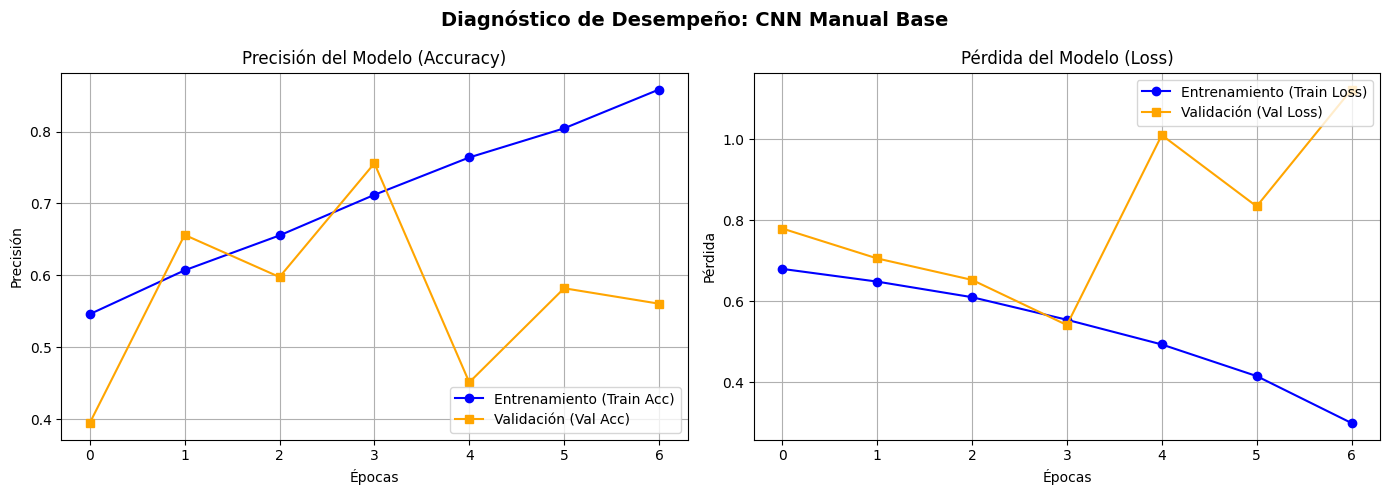

In [ ]:
import matplotlib.pyplot as plt

# Extraemos las métricas del historial de entrenamiento
acc = history_manual.history['accuracy']
val_acc = history_manual.history['val_accuracy']
loss = history_manual.history['loss']
val_loss = history_manual.history['val_loss']
epochs_range = range(len(acc))

# Graficar Precisión y Pérdida lado a lado
plt.figure(figsize=(14, 5))

# Gráfica 1: Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Entrenamiento (Train Acc)', marker='o', color='blue')
plt.plot(epochs_range, val_acc, label='Validación (Val Acc)', marker='s', color='orange')
plt.title('Precisión del Modelo (Accuracy)')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend(loc='lower right')
plt.grid(True)

# Gráfica 2: Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Entrenamiento (Train Loss)', marker='o', color='blue')
plt.plot(epochs_range, val_loss, label='Validación (Val Loss)', marker='s', color='orange')
plt.title('Pérdida del Modelo (Loss)')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend(loc='upper right')
plt.grid(True)

plt.suptitle("Diagnóstico de Desempeño: CNN Manual Base", fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

## Bloque 4: Regularización mediante Aumento de Datos (Data Augmentation) y Dropout

Como pudimos diagnosticar en las gráficas anteriores, nuestro modelo sufre de un sobreajuste severo debido a la escasez de datos (solo 2,000 imágenes de entrenamiento). Para solucionar esto sin salir a buscar nuevas fotografías, utilizaremos dos técnicas de regularización fundamentales:

### 1. Aumento de Datos (Data Augmentation)
Consiste en generar **variedad sintética** a partir de nuestras imágenes originales mediante transformaciones geométricas aleatorias (volteos horizontales, rotaciones, zooms).
* **Por qué funciona:** Al hacer esto, la red neuronal jamás verá exactamente la misma imagen dos veces durante el entrenamiento. Esto rompe la memorización por píxel y fuerza a la red a buscar rasgos verdaderamente genéricos (ej. la forma de las orejas o la nariz, sin importar si están inclinadas o invertidas).

### 2. Dropout (Capa de Abandono)
Justo antes de la capa de clasificación, introduciremos un `layers.Dropout(0.5)`. Esta capa "apaga" aleatoriamente al 50% de las neuronas en cada paso del entrenamiento.
* **Por qué funciona:** Evita que las neuronas densas co-dependan demasiado entre sí, obligando a todo el sistema a desarrollar representaciones robustas y redundantes para clasificar la imagen.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# 1. Definimos secuencialmente las capas de distorsión aleatoria
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal", name="Volteo_Horizontal"),
    layers.RandomRotation(0.1, name="Rotacion_Aleatoria"),
    layers.RandomZoom(0.1, name="Zoom_Aleatoria"),
], name="Pipeline_Data_Augmentation")

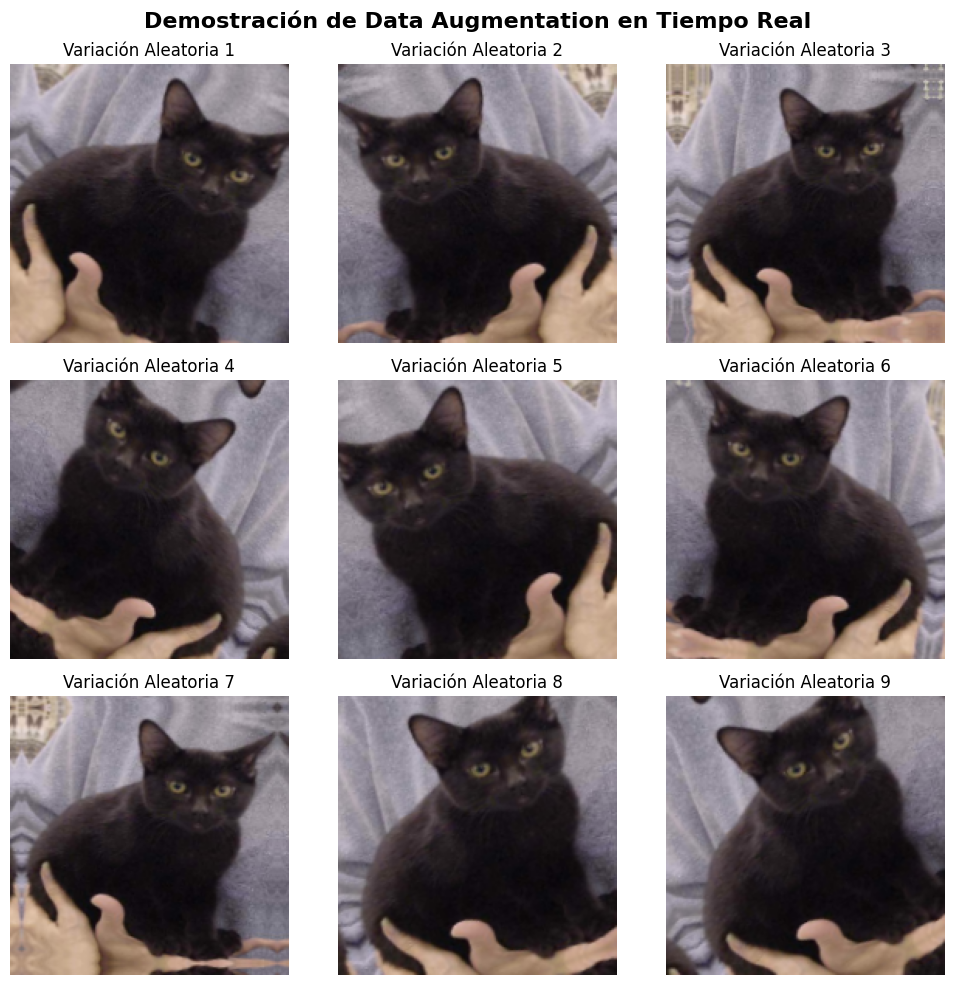

In [ ]:
# 2. DEMOSTRACIÓN VISUAL EN VIVO PARA LA CLASE
plt.figure(figsize=(10, 10))

# Tomamos 1 lote, extraemos la primera imagen
for imagenes, _ in train_dataset.take(1):
    primera_imagen = imagenes[0]

    # Mostramos la evolución de esa misma imagen bajo 9 transformaciones distintas
    for i in range(9):
        # Keras exige que la entrada tenga una dimensión de Batch, por eso usamos expand_dims
        imagen_aumentada = data_augmentation(tf.expand_dims(primera_imagen, 0))

        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(imagen_aumentada[0].numpy().astype("uint8"))
        plt.title(f"Variación Aleatoria {i+1}")
        plt.axis("off")

plt.suptitle("Demostración de Data Augmentation en Tiempo Real", fontsize=16, weight='bold')
plt.tight_layout()
plt.show()

### Integración del Pipeline en la Red Convolucional

Aprovechando la flexibilidad de la **API Funcional**, inyectaremos nuestro bloque `data_augmentation` justo después del tensor de entrada.

*Nota de ingeniería:* Las capas de `DataAugmentation` tienen un comportamiento inteligente incorporado en Keras: **solo se activan durante `model.fit()`**. Cuando usemos el modelo para evaluar o predecir (`model.evaluate()`), estas capas se apagarán automáticamente para no alterar las imágenes de prueba reales.

In [ ]:
# =====================================================================
# CNN MEJORADA CON REGULARIZACIÓN (API FUNCIONAL)
# =====================================================================

inputs = keras.Input(shape=(180, 180, 3), name="Input_Visual")
# PASO 1: Aplicar aumento de datos aleatorio
x = data_augmentation(inputs)
# PASO 2: Normalización de píxeles
x = layers.Rescaling(1./255, name="Normalizacion_Pixeles")(x)
# Bloque Convolucional 1: Extrae características de bajo nivel
x = layers.Conv2D(filters=32, kernel_size=(3, 3), activation="relu", name="Conv_1")(x)
x = layers.MaxPooling2D(pool_size=(2, 2), name="Max_Pool_1")(x)

# Bloque Convolucional 2: Características intermedias
x = layers.Conv2D(filters=64, kernel_size=(3, 3), activation="relu", name="Conv_2")(x)
x = layers.MaxPooling2D(pool_size=(2, 2), name="Max_Pool_2")(x)

# Bloque Convolucional 3: Características complejas/abstractas
x = layers.Conv2D(filters=128, kernel_size=(3, 3), activation="relu", name="Conv_3")(x)
x = layers.MaxPooling2D(pool_size=(2, 2), name="Max_Pool_3")(x)

# Cabeza Clasificadora (Aplanamos el volumen 3D a un vector 1D)
x = layers.Flatten(name="Aplanado_Volumen")(x)

# ¡NUEVA CAPA!: Dropout del 50% para romper co-dependencias neurónales
x = layers.Dropout(0.5, name="Capa_Dropout")(x)

x = layers.Dense(64, activation="relu", name="Capa_Densa_Intermedia")(x)

# Salida Binaria: Sigmoid nos da la probabilidad de ser Perro (1) frente a Gato (0)
outputs = layers.Dense(1, activation="sigmoid", name="Output_Clasificador")(x)

# Amarrar el modelo final
#model_manual = keras.Model(inputs=inputs, outputs=outputs, name="CNN_Manual_Base")
model_regularizado = keras.Model(inputs=inputs, outputs=outputs, name="CNN_Manual_Regularizada")

# 3. COMPILACIÓN: Configuramos la pérdida binaria y el optimizador Adam
model_regularizado.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Mostrar la arquitectura completa en pantalla para la clase
model_regularizado.summary()


Model: "CNN_Manual_Regularizada"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input_Visual (InputLayer)       │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pipeline_Data_Augmentation      │ (None, 180, 180, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Normalizacion_Pixeles           │ (None, 180, 180, 3)    │             0 │
│ (Rescaling)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_1 (Conv2D)                 │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Max_Pool_1 (MaxPooling2D)       │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_2 (Conv2D)                 │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Max_Pool_2 (MaxPooling2D)       │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_3 (Conv2D)                 │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Max_Pool_3 (MaxPooling2D)       │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Aplanado_Volumen (Flatten)      │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Capa_Dropout (Dropout)          │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Capa_Densa_Intermedia (Dense)   │ (None, 64)             │     3,276,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Clasificador (Dense)     │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,370,177 (12.86 MB)

 Trainable params: 3,370,177 (12.86 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Definimos una función generadora para asegurar que cada modelo
# reciba objetos NUEVOS en memoria y guarde su propio archivo independiente.
def obtener_callbacks_experimento(nombre_modelo):
    return [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=3,
            restore_best_weights=True
        ),
        tf.keras.callbacks.ModelCheckpoint(
            # Cada modelo tendrá su propio archivo personalizado en el disco
            filepath=f"mejor_modelo_{nombre_modelo}.keras",
            save_best_only=True,
            monitor="val_loss"
        )
    ]

print("Función generadora de Callbacks configurada con éxito.")

Función generadora de Callbacks configurada con éxito.


In [ ]:
# Entrenamos a 15 épocas guardando el historial en 'history_regularizado'
history_regularizado = model_regularizado.fit(
    train_dataset,
    epochs=15,
    validation_data=validation_dataset,
    callbacks=obtener_callbacks_experimento("manual_regularizado")
    #callbacks=mis_callbacks # Reutilizamos nuestro EarlyStopping inteligente
)

Epoch 1/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - accuracy: 0.7195 - loss: 0.5558 - val_accuracy: 0.6450 - val_loss: 0.6484
Epoch 2/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - accuracy: 0.7225 - loss: 0.5483 - val_accuracy: 0.7180 - val_loss: 0.5648
Epoch 3/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - accuracy: 0.7415 - loss: 0.5261 - val_accuracy: 0.7130 - val_loss: 0.5519
Epoch 4/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.7390 - loss: 0.5266 - val_accuracy: 0.7340 - val_loss: 0.5395
Epoch 5/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - accuracy: 0.7305 - loss: 0.5308 - val_accuracy: 0.7200 - val_loss: 0.5534
Epoch 6/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.7555 - loss: 0.5102 - val_accuracy: 0.7310 - val_loss: 0.5330
Epoch 7/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - accuracy: 0.7595 - loss: 0.5079 - val_accuracy: 0.7400 - val_loss: 0.5479
Epoch 8/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 71ms/step - accuracy: 0.7455 - loss: 0.5256 - val_accuracy: 0.6730 - v

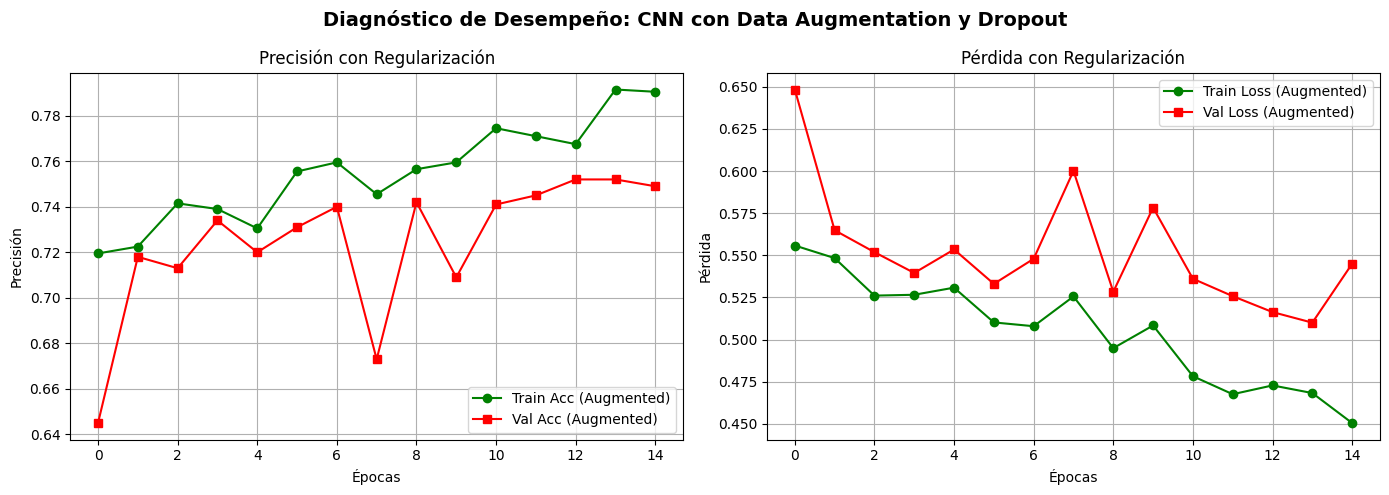

In [ ]:
acc = history_regularizado.history['accuracy']
val_acc = history_regularizado.history['val_accuracy']
loss = history_regularizado.history['loss']
val_loss = history_regularizado.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))

# Gráfica 1: Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Train Acc (Augmented)', marker='o', color='green')
plt.plot(epochs_range, val_acc, label='Val Acc (Augmented)', marker='s', color='red')
plt.title('Precisión con Regularización')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend(loc='lower right')
plt.grid(True)

# Gráfica 2: Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Train Loss (Augmented)', marker='o', color='green')
plt.plot(epochs_range, val_loss, label='Val Loss (Augmented)', marker='s', color='red')
plt.title('Pérdida con Regularización')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend(loc='upper right')
plt.grid(True)

plt.suptitle("Diagnóstico de Desempeño: CNN con Data Augmentation y Dropout", fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

## Bloque 4B: Evaluación del Modelo e Inferencia (Predict)

Una vez que un modelo ha terminado de entrenarse, un ingeniero en IA debe dominar dos operaciones distintas para ponerlo a prueba:

### 1. Evaluación (`model.evaluate`)
* **Qué hace:** Toma un conjunto de datos completo que el modelo jamás vio durante el entrenamiento (en nuestro caso, el set de validación) y calcula de golpe la pérdida global y las métricas elegidas (Accuracy).
* **Para qué sirve:** Nos da el veredicto final sobre el rendimiento estadístico del modelo.

### 2. Inferencia / Predicción (`model.predict`)
* **Qué hace:** Toma una o varias imágenes individuales libres y calcula la salida matemática de la red (en nuestro caso, una probabilidad entre 0 y 1 gracias a la función `sigmoid`).
* **Para qué sirve:** Es el modo en que el modelo opera en el mundo real (ej. cuando subes una foto a una app y la IA te dice qué animal es).

---
### 🛠️ Regla de Oro para la Inferencia de un Píxel Individual

Un error muy común al usar `model.predict()` es pasarle una imagen de dimensiones `(180, 180, 3)`. Si hacen esto, TensorFlow arrojará un error de dimensiones (*ValueError*).

**¿Por qué?** Porque las capas convolucionales de Keras están diseñadas matemáticamente para procesar **lotes (batches)** de imágenes en paralelo. Por lo tanto, aunque queramos predecir una sola foto, estamos obligados a "engañar" a la red expandiendo sus dimensiones para simular un lote de tamaño 1: **`(1, 180, 180, 3)`**.

In [ ]:
print("====================================================")
print("   EVALUACIÓN FORMAL DE LOS MODELOS (TEST/VAL)      ")
print("====================================================")

# 1. Evaluar el modelo base manual
loss_base, acc_base = model_manual.evaluate(validation_dataset, verbose=0)
print(f"1. CNN Manual Base         -> Pérdida: {loss_base:.4f} | Precisión (Accuracy): {acc_base*100:.2f}%")

# 2. Evaluar el modelo regularizado (con Data Augmentation y Dropout)
loss_reg, acc_reg = model_regularizado.evaluate(validation_dataset, verbose=0)
print(f"2. CNN Manual Regularizada -> Pérdida: {loss_reg:.4f} | Precisión (Accuracy): {acc_reg*100:.2f}%")

print("====================================================")

   EVALUACIÓN FORMAL DE LOS MODELOS (TEST/VAL)      
1. CNN Manual Base         -> Pérdida: 0.6074 | Precisión (Accuracy): 69.30%
2. CNN Manual Regularizada -> Pérdida: 0.5100 | Precisión (Accuracy): 75.20%


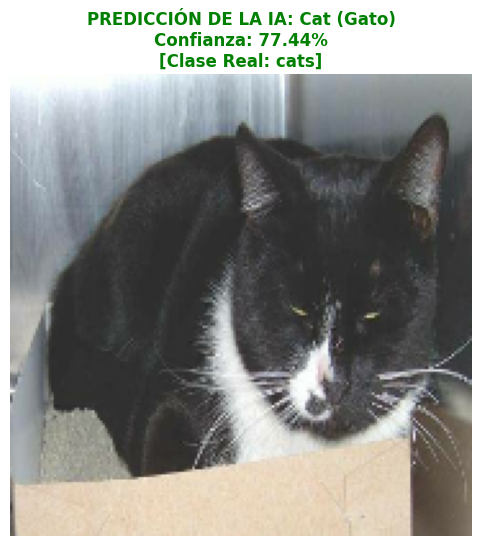

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Extraemos un lote del set de validación para tomar una imagen de prueba
for imagenes_val, etiquetas_val in val_dataset_puro.take(1):
    # Tomamos la primera imagen y su etiqueta real del lote
    img_individual = imagenes_val[1]
    etiqueta_real = etiquetas_val[1].numpy()
    break

# 2. EXPANDIR DIMENSIONES (Pasar de 3D a 4D para cumplir la regla de Keras)
# Pasa de (180, 180, 3) a (1, 180, 180, 3)
img_preparada = tf.expand_dims(img_individual, axis=0)

# 3. EJECUTAR LA INFERENCIA (PREDICT)
# predict() nos devuelve un arreglo con la probabilidad flotante
prediccion_cruda = model_regularizado.predict(img_preparada, verbose=0)
probabilidad = prediccion_cruda[0][0]

# 4. INTERPRETACIÓN DEL SIGMOID (> 0.5 es Perro (1), <= 0.5 es Gato (0))
if probabilidad > 0.5:
    clase_predicha = "Dog (Perro)"
    confianza = probabilidad * 100
else:
    clase_predicha = "Cat (Gato)"
    confianza = (1 - probabilidad) * 100

# Traducir la etiqueta real numérica a texto para comparar
clase_real = nombres_clases[etiqueta_real]

# 5. VISUALIZACIÓN DEL RESULTADO EN PANTALLA
plt.figure(figsize=(6, 6))
plt.imshow(img_individual.numpy().astype("uint8"))

# Color del título: Verde si acertó, Rojo si se equivocó
color_titulo = 'green' if clase_predicha.lower().startswith(clase_real.lower()[:3]) else 'red'

plt.title(f"PREDICCIÓN DE LA IA: {clase_predicha}\nConfianza: {confianza:.2f}%\n[Clase Real: {clase_real}]",
          color=color_titulo, fontsize=12, weight='bold')
plt.axis("off")
plt.show()

# Bloque 5: Aprendizaje por Transferencia (Transfer Learning) Colectivo

En las etapas anteriores descubrimos que diseñar una red desde cero con pocos datos tiene un techo estadístico bajo. En la industria real, rara vez se entrena una CNN grande desde cero. En su lugar, aplicamos **Transfer Learning**.

### ¿Por qué funciona?
Las grandes empresas (Google, Microsoft, Meta) entrenan modelos monstruosos con millones de imágenes (como el dataset *ImageNet* de 1,000 categorías) utilizando supercomputadoras durante semanas.
En ese proceso, las primeras capas del modelo aprendieron a reconocer bordes, texturas y formas universales del mundo visual. El **Aprendizaje por Transferencia** consiste en tomar esa base de conocimiento ya consolidada (*Backbone*) y reutilizarla para nuestro problema específico de Perros y Gatos.

---

### 🛠️ Las Dos Fases del Proceso

Hoy ejecutaremos la **Fase 1: Extracción de Características (Feature Extraction)**.

1. **Congelar la Base Convolucional (`base_model.trainable = False`):** Tomamos el esqueleto preentrenado y bloqueamos sus pesos. No queremos que el optimizador altere el conocimiento que ya tiene sobre el mundo visual.
2. **Cortar y Reemplazar la Cabeza Clasificadora:** Eliminamos el clasificador original de 1,000 clases de ImageNet e inyectamos una nueva capa densa con salida `sigmoid` adaptada a nuestras 2 clases (Perro/Gato).
3. **Entrenar Exclusivamente el Clasificador Nuevo:** Al correr el `.fit()`, el gradiente solo modificará los pesos de nuestra capa final. El esqueleto solo actuará como un extractor de rasgos ultra-sofisticado en modo de "solo lectura".

---

### 📐 Un Cambio de Ingeniería: `GlobalAveragePooling2D` vs `Flatten`

En nuestra CNN manual usamos `Flatten` para convertir el volumen de datos 3D en un vector 1D antes de la capa densa. En Transfer Learning, las bases preentrenadas devuelven mapas de características densos. Si usáramos `Flatten`, generaríamos millones de parámetros en la capa final, provocando sobreajuste inmediato.

En su lugar, utilizaremos **`GlobalAveragePooling2D`**: esta capa toma cada canal de características completo y calcula su promedio matemático, reduciendo el espacio espacial a un solo número por canal. Es el patrón moderno de diseño que revisamos en el Capítulo 9 para compactar redes de forma elegante.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# =====================================================================
# PLANTILLA GLOBAL DE TRANSFER LEARNING (FEATURE EXTRACTION)
# =====================================================================

# ⚠️ ENTRADA PARA EQUIPOS: Cambien la línea de abajo por la arquitectura asignada
# Opciones comunes: VGG16, ResNet50V2, Xception, MobileNetV2, DenseNet121

print("Cargando base convolucional preentrenada con ImageNet...")
base_model = keras.applications.ResNet50V2(
    weights='imagenet',       # Cargar los pesos matemáticos ideales ya entrenados
    include_top=False,        # FALSE: Corta la cabeza clasificadora original de 1000 clases
    input_shape=(180, 180, 3) # Adaptar el tamaño de entrada a nuestras imágenes
)


Cargando base convolucional preentrenada con ImageNet...
94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
# REGLA DE ORO 1: Congelar por completo los pesos de la base preentrenada
base_model.trainable = False

In [ ]:
# REGLA DE ORO 2: Configurar la función de preprocesamiento específica de la arquitectura
# Cada red procesa los colores de forma distinta (ej. rango [-1, 1], centrado en cero, etc.)
# ⚠️ EQUIPOS: Asegurense de usar el preprocess_input correspondiente a su red.
procesamiento_red = keras.applications.resnet_v2.preprocess_input

In [ ]:

# =====================================================================
# CONSTRUCCIÓN DEL GRAFO (API FUNCIONAL)
# =====================================================================
inputs = keras.Input(shape=(180, 180, 3), name="Input_Equipos")

# 1. Aplicamos el Data Augmentation que ya validamos
x = data_augmentation(inputs)

# 2. Aplicamos el preprocesamiento de color requerido por esta red específica
x = procesamiento_red(x)

# 3. Pasamos el tensor por la base congelada
# NOTA: training=False asegura que las capas de BatchNormalization operen en modo inferencia
x = base_model(x, training=False)

# 4. Reducción dimensional inteligente en lugar de Flatten
x = layers.GlobalAveragePooling2D(name="Compactacion_Espacial")(x)

# 5. Capa de Dropout preventiva leve para la nueva cabeza
x = layers.Dropout(0.2, name="Regularizacion_Cabeza")(x)

# 6. Salida Binaria Final
outputs = layers.Dense(1, activation='sigmoid', name="Output_Clasificador_Equipos")(x)

# Construcción y Compilación del modelo de Transfer Learning
model_transfer = keras.Model(inputs=inputs, outputs=outputs, name="Modelo_Transfer_Learning")

model_transfer.compile(
    optimizer="adam", # Al estar la base congelada, Adam a velocidad normal (1e-3) es seguro
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_transfer.summary()

Model: "Modelo_Transfer_Learning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input_Equipos (InputLayer)      │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pipeline_Data_Augmentation      │ (None, 180, 180, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 6, 6, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Compactacion_Espacial           │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Regularizacion_Cabeza (Dropout) │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Clasificador_Equipos     │ (None, 1)              │         2,049 │
│ (Dense)                         │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,566,849 (89.90 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,564,800 (89.89 MB)

In [ ]:
# Invocamos callbacks frescos con un identificador único para este experimento
# Entrenar solo 5 épocas es suficiente (converge a la velocidad de la luz)
history_transfer = model_transfer.fit(
    train_dataset,
    epochs=5,
    validation_data=val_dataset_puro,
    callbacks=obtener_callbacks_experimento("transfer_learning_equipos")
)

In [ ]:
# Evaluamos el veredicto final sobre el conjunto de prueba ciego (Test Set)
loss_test, acc_test = model_transfer.evaluate(test_dataset, verbose=0)

print("\n====================================================")
print("             VEREDICTO DE TRANSFER LEARNING         ")
print("====================================================")
print(f" Precisión Final en el TEST SET: {acc_test * 100:.2f}%")
print(f" Pérdida Final en el TEST SET: {loss_test:.4f}")
print("====================================================")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Extraemos un lote del set de validación para tomar una imagen de prueba
for imagenes_val, etiquetas_val in validation_dataset.take(1):
    # Tomamos la primera imagen y su etiqueta real del lote
    img_individual = imagenes_val[3]
    etiqueta_real = etiquetas_val[3].numpy()
    break

# 2. EXPANDIR DIMENSIONES (Pasar de 3D a 4D para cumplir la regla de Keras)
# Pasa de (180, 180, 3) a (1, 180, 180, 3)
img_preparada = tf.expand_dims(img_individual, axis=0)

# 3. EJECUTAR LA INFERENCIA (PREDICT)
# predict() nos devuelve un arreglo con la probabilidad flotante
prediccion_cruda = model_transfer.predict(img_preparada, verbose=0)
probabilidad = prediccion_cruda[0][0]

# 4. INTERPRETACIÓN DEL SIGMOID (> 0.5 es Perro (1), <= 0.5 es Gato (0))
if probabilidad > 0.5:
    clase_predicha = "Dog (Perro)"
    confianza = probabilidad * 100
else:
    clase_predicha = "Cat (Gato)"
    confianza = (1 - probabilidad) * 100

# Traducir la etiqueta real numérica a texto para comparar
clase_real = nombres_clases[etiqueta_real]

# 5. VISUALIZACIÓN DEL RESULTADO EN PANTALLA
plt.figure(figsize=(6, 6))
plt.imshow(img_individual.numpy().astype("uint8"))

# Color del título: Verde si acertó, Rojo si se equivocó
color_titulo = 'green' if clase_predicha.lower().startswith(clase_real.lower()[:3]) else 'red'

plt.title(f"PREDICCIÓN DE LA IA: {clase_predicha}\nConfianza: {confianza:.2f}%\n[Clase Real: {clase_real}]",
          color=color_titulo, fontsize=12, weight='bold')
plt.axis("off")
plt.show()

# Bloque 6: Inteligencia Artificial Explicable (XAI) y Mapas de Activación (Grad-CAM)

A fundamental problem when building a computer vision application is that of interpretability: Why did your classifier think a particular image contained a fridge, when all you can see is a truck? This is especially relevant to use cases where deep learning is used to complement human expertise, such as medical imaging use cases. This chapter will get you familiar with a range of different techniques for visualizing what ConvNets learn and understanding the decisions they make.

It’s often said that deep learning models are “black boxes”: they learn representations that are difficult to extract and present in a human-readable form. Although this is partially true for certain types of deep learning models, it’s definitely not true for ConvNets. The representations learned by ConvNets are highly amenable to visualization, in large part because they’re representations of visual concepts. Since 2013, a wide array of techniques has been developed for visualizing and interpreting these representations. We won’t survey all of them, but we’ll cover three of the most accessible and useful ones:

* Visualizing intermediate ConvNet outputs (intermediate activations) — Useful for understanding how successive ConvNet layers transform their input, and for getting a first idea of the meaning of individual ConvNet filters
* Visualizing ConvNets filters — Useful for understanding precisely what visual pattern or concept each filter in a ConvNet is receptive to
* Visualizing heatmaps of class activation in an image — Useful for understanding which parts of an image were identified as belonging to a given class, thus allowing you to localize objects in images

CARGAR MODELOS ENTRENADOS

In [ ]:
import os
os.environ["KERAS_BACKEND"] = "torch"
import keras
import numpy as np


# =====================================================================
# RECUPERACIÓN DE MODELOS
# =====================================================================

# Ruta donde se guardaron sus modelos (ajuste según su estructura de carpetas)
ruta_modelo_manual = "mejor_modelo_manual_regularizado.keras"
ruta_modelo_transfer = "mejor_modelo_transfer_learning_equipos.keras"

print("Cargando modelos desde el disco...")

# 1. Cargar el modelo completo
model_manual_cargado = keras.models.load_model(ruta_modelo_manual)
model_transfer = keras.models.load_model(ruta_modelo_transfer)

print("Modelos cargados exitosamente.")

KeyboardInterrupt: 

In [ ]:
# 2. Verificar que el modelo está listo para predecir
# Basta con llamar al summary para confirmar la estructura
model_manual_cargado.summary()

In [ ]:
# 2. Verificar que el modelo está listo para predecir
# Basta con llamar al summary para confirmar la estructura
model_transfer.summary()

## Paso 1: Visualizando Activaciones Intermedias (Visualizing Intermediate ConvNet Outputs)

¿Qué ve nuestra red después de procesar una imagen? Cada capa convolucional es una colección de "filtros" que actúan como detectores de características.

* **Capas iniciales:** Detectan patrones simples (bordes, texturas, líneas).
* **Capas profundas:** Detectan conceptos abstractos (ojos, orejas, patrones de pelaje).

Visualizar esto nos permite confirmar que la red efectivamente está "aprendiendo" jerarquías visuales y no solo memorizando ruido.

In [ ]:
# Downloads the image and stores it locally under the path img_path
img_path = keras.utils.get_file(
    fname="cat.jpg",
    origin="https://img-datasets.s3.amazonaws.com/cat.jpg",
)
# Returns a Python Imaging Library (PIL) image
img = keras.utils.load_img(img_path, target_size=(180, 180))
img_array = np.expand_dims(img, axis=0)

In [ ]:
import matplotlib.pyplot as plt
plt.axis("off")
plt.imshow(img_array[0].astype("uint8"))
plt.show()

In [ ]:
for layer in model_manual_cargado.layers:
    print(layer)

In [ ]:
capas_a_visualizar = [layer.output for layer in model_manual_cargado.layers if 'Conv_' in layer.name]
print(capas_a_visualizar)

In [ ]:
# Suponiendo que 'model_transfer' es nuestro modelo cargado
# Extraemos las salidas de todas las capas convolucionales
#capas_a_visualizar = [layer.output for layer in model_manual_cargado.layers if 'Conv_' in layer.name]
model_visual = keras.Model(inputs=model_manual_cargado.inputs, outputs=capas_a_visualizar)

# Elegimos una imagen de prueba
activaciones = model_visual.predict(img_array)

In [ ]:
print(f'Numero de capas: {len(activaciones)}')
first_layer_activation = activaciones[0]
print(first_layer_activation.shape)

NameError: name 'activaciones' is not defined

In [ ]:
# Visualizamos el primer filtro de la primera capa convolucional
k=2 #numero de feature map, en capa 1 hay 32
plt.matshow(activaciones[0][0, :, :, k], cmap='viridis')
plt.title("Activación de la primera capa Conv_")
plt.show()

In [ ]:
def plot_fm(activaciones, k=100, capa=0):
    """
    k: número de feature maps que quieres visualizar (ej. 16)
    activaciones: debe ser el resultado de model_visual.predict(img_input)
    """
    #0.
    total_capas= len(activaciones)-1
    if capa > total_capas:
        capa = total_capas
    # 1. Obtenemos el número total de filtros disponibles en la capa
    # activaciones[0] es la salida de la primera capa.
    # La forma es (1, altura, ancho, filtros)
    total_filtros = activaciones[capa].shape[-1]

    # 2. Ajustamos k si el usuario pide más filtros de los que tiene la capa
    if k > total_filtros:
        k = total_filtros

    # 3. Configuramos la cuadrícula (ej. 4x4 si pides 16)
    import math
    cols = 4
    rows = math.ceil(k / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(12, 3 * rows))
    fig.suptitle(f"Activaciones de los primeros {k} filtros de la capa {capa}", fontsize=16)

    axes = axes.flatten() # Aplanamos el array de ejes para iterar fácil

    for i in range(k):
        # Seleccionamos el filtro i
        mapa = activaciones[capa][0, :, :, i]

        # Graficamos
        axes[i].imshow(mapa, cmap='viridis')
        axes[i].set_title(f"Filtro {i}")
        axes[i].axis('off')

    # Ocultar los ejes vacíos si k no llena la cuadrícula
    for i in range(k, len(axes)):
        axes[i].axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# --- USO EN CLASE ---
# Llamada simple: Graficar los primeros 16 mapas de activación
plot_fm(activaciones,capa=2)

## Paso 3: Grad-CAM (Heatmaps de Activación)

Este es el punto final. A diferencia de los pasos anteriores, aquí **no vemos qué detecta un filtro, sino qué detecta la red completa para una clase específica**.

La intuición es:
1. Tomamos la última capa convolucional (donde la información es espacialmente rica).
2. Calculamos cuánto influyó cada mapa de características en la decisión final (el "score" de la clase).
3. "Coloreamos" la imagen original basándonos en esa influencia.

![image.png](attachment:983ae6e1-cb84-41a4-ac61-249cc8f59585.png)

In [ ]:
# Downloads the image and stores it locally under the path img_path
img_path = keras.utils.get_file(
    fname="cat.jpg",
    origin="https://img-datasets.s3.amazonaws.com/cat.jpg",
)
# Returns a Python Imaging Library (PIL) image
img = keras.utils.load_img(img_path, target_size=(180, 180))
img_array = np.expand_dims(img, axis=0)
plt.axis("off")
plt.imshow(img_array[0].astype("uint8"))
plt.show()

In [ ]:
# =====================================================================
# RECUPERACIÓN DE MODELOS
# =====================================================================
# Ruta donde se guardaron sus modelos (ajuste según su estructura de carpetas)
ruta_modelo_manual = "mejor_modelo_manual_regularizado.keras"
ruta_modelo_transfer = "mejor_modelo_transfer_learning_equipos.keras"
print("Cargando modelos desde el disco...")
# 1. Cargar el modelo completo
model_manual_cargado = keras.models.load_model(ruta_modelo_manual)
model_transfer = keras.models.load_model(ruta_modelo_transfer)
print("Modelos cargados exitosamente.")

# Esto le dice a Keras/Torch: "¡No apagues neuronas, mantén el modelo fijo!"
model_manual_cargado.eval() # Si es un objeto de Torch nativo
model_transfer.eval()
# O en Keras:
#model_manual_cargado.training = False

### 📑 Identificación y Selección de la Última Capa Convolucional
Para que el algoritmo Grad-CAM funcione correctamente, es crítico identificar la capa exacta donde la red aún conserva información espacial (altura y anchura). Si elegimos una capa situada después de un aplanado (Flatten) o una compactación global (GlobalAveragePooling), la información espacial se habrá perdido, convirtiendo la activación en un valor escalar (un número) que no puede proyectarse sobre la imagen original.

#### 1. Estrategia de Identificación
Podemos inspeccionar la arquitectura de nuestra red utilizando dos métodos principales:

Método A: model.summary(): Es la forma más rápida para visualizar la jerarquía, el tipo de capa y las dimensiones de salida (Output Shape). Buscamos la última capa de tipo Conv2D o SeparableConv2D.

Método B: Iteración sobre model.layers: Ideal si estamos trabajando con modelos complejos o funcionales donde las capas están anidadas.

In [ ]:
model_manual_cargado.layers

##### 💻 Paso 1: La estructura de la función (El "modelo Grad-CAM")
Primero, creamos un modelo intermedio que nos permita extraer simultáneamente la salida de la capa Conv_3 y la salida final del clasificador.

In [ ]:
modelo=model_manual_cargado
nombre_capa_objetivo="Conv_3"
grad_model = keras.Model(
        inputs=modelo.inputs,
        outputs=[modelo.get_layer(nombre_capa_objetivo).output, modelo.output]
    )

##### 💻 Paso 2: El cálculo de los gradientes (La "cinta de grabación")
Ahora usaremos tf.GradientTape. Esta herramienta es como una "cinta de grabación" que rastrea todas las operaciones matemáticas para poder calcular la derivada (gradiente) después.

In [ ]:
conv_outputs, predicciones = grad_model({"Input_Visual": img_array})

In [ ]:
predicciones

In [ ]:
conv_outputs

CALCULO DE GRADIENTES CON PYTORCH

In [ ]:
# 1. Convertir el input a un tensor de PyTorch si no lo es
# Aseguramos que sea float32
input_tensor = torch.tensor(img_array, dtype=torch.float32)

In [ ]:
# Si su modelo espera un batch, aseguramos que tenga la dimensión correcta
if input_tensor.dim() == 3:
    input_tensor = input_tensor.unsqueeze(0)

In [ ]:
# 2. Activar el rastreo de gradientes (similar a tape.watch)
input_tensor.requires_grad = True

In [ ]:
# 3. Forward pass (pasamos el input por el modelo)
# Como es un modelo funcional de Keras con backend Torch, funciona como una función
conv_outputs, predicciones = grad_model(input_tensor)

In [ ]:
# 4. Seleccionar el score de la clase
clase_score = predicciones[:, 0]

In [ ]:
# 5. Calcular gradientes con PyTorch
# Backward sobre el score para obtener los gradientes respecto a conv_outputs
clase_score.backward()

In [ ]:
# Los gradientes ahora están almacenados en conv_outputs.grad
grads = conv_outputs.grad

In [ ]:
def obtener_gradientes_torch(img_array, grad_model):
    # 1. Convertir el input a un tensor
    input_tensor = torch.tensor(img_array, dtype=torch.float32)
    if input_tensor.dim() == 3:
        input_tensor = input_tensor.unsqueeze(0)

    # 2. Activar el rastreo de gradientes (similar a tape.watch)
    input_tensor.requires_grad = True

    # 3. Forward pass (pasamos el input por el modelo)
    # Como es un modelo funcional de Keras con backend Torch, funciona como una función
    #conv_outputs, predicciones = grad_model(input_tensor)
    conv_outputs, predicciones = grad_model(input_tensor, training=False)

    # --- LA CLAVE ESTÁ AQUÍ ---
    # Le decimos a PyTorch que NO borre el gradiente de este tensor
    conv_outputs.retain_grad()
    # --------------------------

    # Calcular gradientes
    # 4. Seleccionar el score de la clase
    clase_score = predicciones[:, 0]
    # 5. Calcular gradientes con PyTorch
    # Backward sobre el score para obtener los gradientes respecto a conv_outputs
    clase_score.backward()

    # Los gradientes ahora están almacenados en conv_outputs.grad
    grads = conv_outputs.grad

    return conv_outputs, grads

conv_outputs, grads = obtener_gradientes_torch(img_array, grad_model)

In [ ]:
# 1. Promediar los gradientes por canal (Global Average Pooling)
# grads tiene forma (1, H, W, Canales), queremos (Canales)
weights = torch.mean(grads, dim=(0, 1, 2))

# 2. Multiplicar las activaciones por los pesos (suma ponderada)
# conv_outputs tiene forma (1, H, W, Canales)
heatmap = torch.sum(weights * conv_outputs, dim=-1)

# 3. Aplicar ReLU para ignorar lo que no contribuye positivamente
heatmap = torch.relu(heatmap)

# 4. Normalizar el mapa para que esté entre 0 y 1 (para visualización)
heatmap = heatmap / torch.max(heatmap)

# Convertir a numpy para usarlo con Matplotlib
heatmap_np = heatmap.detach().cpu().numpy().squeeze()

In [ ]:
plt.matshow(heatmap_np)

In [ ]:
import matplotlib.pyplot as plt
import cv2

# Redimensionar el mapa de calor al tamaño de la imagen original
heatmap_resized = cv2.resize(heatmap_np, (180, 180))

# Crear una máscara de color (Jet es el estándar para mapas de calor)
heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)

# Convertir la imagen original a uint8 y BGR para OpenCV
img_original = img_array[0].astype("uint8")
img_bgr = cv2.cvtColor(img_original, cv2.COLOR_RGB2BGR)

# Mezclar la imagen original con el mapa de calor
superposicion = cv2.addWeighted(img_bgr, 0.5, heatmap_color, 0.5, 0)

# Mostrar resultado
plt.imshow(cv2.cvtColor(superposicion, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [ ]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt

def visualizar_gradcam(modelo, nombre_capa, img_array):
    """
    modelo: El modelo cargado (ej. model_manual_cargado)
    nombre_capa: string con el nombre de la capa conv (ej. 'Conv_3')
    img_array: el array de la imagen (1, 180, 180, 3)
    """
    # 0. Preparativos
    modelo.eval()
    modelo.zero_grad()

    # Crear modelo funcional para extraer capa intermedia
    grad_model = keras.Model(inputs=modelo.inputs,
                             outputs=[modelo.get_layer(nombre_capa).output, modelo.output])

    # 1. Preparar tensor
    input_tensor = torch.tensor(img_array, dtype=torch.float32)
    if input_tensor.dim() == 3: input_tensor = input_tensor.unsqueeze(0)
    input_tensor.requires_grad = True

    # 2. Forward pass
    #conv_outputs, predicciones = grad_model(input_tensor)
    conv_outputs, predicciones = grad_model(input_tensor, training=False)
    conv_outputs.retain_grad()

    # 3. Backward pass
    clase_score = predicciones[:, 0]
    clase_score.backward()

    # 4. Cálculo de Heatmap
    grads = conv_outputs.grad
    weights = torch.mean(grads, dim=(0, 1, 2))
    heatmap = torch.sum(weights * conv_outputs, dim=-1)
    heatmap = torch.relu(heatmap)
    heatmap = heatmap / (torch.max(heatmap) + 1e-8) # Evitar división por cero

    # 5. Obtener el score y decidir la etiqueta
    score = clase_score.item()
    # Asumimos: 0 = Gato, 1 = Perro (ajuste según su modelo si es al revés)
    etiqueta = "Perro" if score > 0.5 else "Gato"
    probabilidad = score if score > 0.5 else (1 - score)

    # 6. Post-procesamiento visual (heatmap y superposición)
    heatmap_np = heatmap.squeeze().detach().cpu().numpy()
    heatmap_resized = cv2.resize(heatmap_np, (180, 180))
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

    img_original = img_array[0].astype("uint8")
    superposicion = cv2.addWeighted(img_original, 0.6, heatmap_color, 0.4, 0)

    # 7. Graficar con información clara
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1); plt.imshow(img_original); plt.title("Original"); plt.axis("off")
    plt.subplot(1, 2, 2); plt.imshow(superposicion)
    plt.title(f"Predicción: {etiqueta}\nConfianza: {probabilidad*100:.1f}%")
    plt.axis("off")
    plt.show()

# --- USO ---
visualizar_gradcam(model_manual_cargado, 'Conv_3', img_array)

EJEMPLO CON RESNET50

In [ ]:
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input

model = ResNet50(weights='imagenet')

# 2. Preparar tu imagen (ajustada a 224x224)
#img_path = 'tu_imagen.jpg' # Cambia esto por tu archivo
#img = image.load_img(img_path, target_size=(224, 224))
#x = image.img_to_array(img)
#x = np.expand_dims(x, axis=0)
x = preprocess_input(img_array) # ResNet necesita este preprocesamiento específico

In [ ]:
# Downloads the image and stores it locally under the path img_path
img_path = keras.utils.get_file(
    fname="cat.jpg",
    origin="https://img-datasets.s3.amazonaws.com/cat.jpg",
)
# Returns a Python Imaging Library (PIL) image
img = keras.utils.load_img(img_path, target_size=(224, 224))
img_array_224 = np.expand_dims(img, axis=0)
plt.axis("off")
plt.imshow(img_array_224[0].astype("uint8"))
plt.show()

In [ ]:
# Downloads the image and stores it locally under the path img_path
img_path = keras.utils.get_file(
    fname="cat.jpg",
    origin="https://img-datasets.s3.amazonaws.com/cat.jpg",
)
# Returns a Python Imaging Library (PIL) image
img = keras.utils.load_img(img_path, target_size=(224, 224))
img_array_224 = np.expand_dims(img, axis=0)
plt.axis("off")
plt.imshow(img_array_224[0].astype("uint8"))
plt.show()

In [ ]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications.resnet50 import decode_predictions

def visualizar_gradcam_resnet(modelo, nombre_capa, img_array):
    # 0. Preparativos
    modelo.eval()
    modelo.zero_grad()

    grad_model = keras.Model(inputs=modelo.inputs,
                             outputs=[modelo.get_layer(nombre_capa).output, modelo.output])

    # 1. Preparar tensor
    input_tensor = torch.tensor(img_array, dtype=torch.float32)
    if input_tensor.dim() == 3: input_tensor = input_tensor.unsqueeze(0)
    input_tensor.requires_grad = True

    # 2. Forward pass
    conv_outputs, predicciones = grad_model(input_tensor)
    conv_outputs.retain_grad()

    # 3. Backward pass (Seleccionamos la clase con mayor probabilidad)
    # ResNet devuelve (1, 1000), buscamos el índice máximo
    clase_idx = torch.argmax(predicciones[0])
    clase_score = predicciones[0, clase_idx]
    clase_score.backward()

    # 4. Cálculo de Heatmap
    grads = conv_outputs.grad
    weights = torch.mean(grads, dim=(0, 1, 2))
    heatmap = torch.sum(weights * conv_outputs, dim=-1)
    heatmap = torch.relu(heatmap)
    heatmap = heatmap / (torch.max(heatmap) + 1e-8)

    # 5. Obtener etiqueta de ImageNet
    # Convertimos a numpy para decodificar con Keras
    pred_np = predicciones.detach().cpu().numpy()
    # Usamos la utilidad de Keras para saber qué objeto es
    etiqueta_data = decode_predictions(pred_np, top=1)[0][0]
    nombre_clase = etiqueta_data[1]
    probabilidad = etiqueta_data[2]

    # 6. Post-procesamiento (Dimensiones 224x224 típicas de ResNet)
    heatmap_np = heatmap.squeeze().detach().cpu().numpy()
    heatmap_resized = cv2.resize(heatmap_np, (224, 224))
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

    img_original = img_array[0].astype("uint8")
    superposicion = cv2.addWeighted(img_original, 0.6, heatmap_color, 0.4, 0)

    # 7. Graficar
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1); plt.imshow(img_original); plt.title("Original"); plt.axis("off")
    plt.subplot(1, 2, 2); plt.imshow(superposicion)
    plt.title(f"Predicción: {nombre_clase}\nConfianza: {probabilidad*100:.1f}%")
    plt.axis("off")
    plt.show()

# --- USO ---
# Importante: ResNet50 espera 224x224
model = ResNet50(weights='imagenet')
visualizar_gradcam_resnet(model, 'conv5_block3_out', img_array_224)